# Eviny Charging Curve Classification LSTM 
#### by Sebastian Einar Salas Røkholt
----

### Index
**1. Setup** </br>
**2. Data Exploration, Wrangling and Preprocessing**</br>
**3. Modelling**</br>
**4. Model Evaluation and Selection**</br>
**+++**</br>


### Introduction
The aim of this notebook is ...

 ### 1. Setup

In [2]:
import os
import math
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Sampler
import torch.nn.utils.rnn as rnn_utils
from torch.amp import autocast, GradScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
from typing import Tuple, Union, List

RANDOM_SEED = 42
BATCH_SIZE = 256
NUM_WORKERS = 8
TRAIN_MODEL = False
MODEL_PATH = '../Models/LSTM_varseq_multistep_model_3.pth'
HORIZON = 5  # The number of next time steps to predict
HIDDEN_DIM = 256
NUM_LAYERS = 4
NUM_EPOCHS = 200

# PyTorch settings
torch.manual_seed(RANDOM_SEED)

# Notebook settings
%matplotlib inline
pd.options.mode.copy_on_write = True
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.options.display.float_format = '{:.2f}'.format


#### 1.1 Feature selection 
In order to predict `soc` and `power` output for the next `HORIZON` (e.g. 5) timesteps, the model will use the `soc` and `power` values from the `sequence_length` (e.g. 15) previous timesteps/minutes. In addition, there are two static (non time-dependent, per-session) features that we believe the model will use to enhance its predictive abilities. The first static feature is `temp`, the approximate ambient temperature (rounded to the nearest integer) at the start of the charging session. Charging speed is directly influenced by the vehicle's battery temperature, because at lower temperatures, the chemical processes in the battery slow down. Lithium-ion batteries may also experience lithium plating if charged to quickly at low temperatures, so both vehicle and charging station manufacturers place automatic restrictions that limit the energy transfer. As we do not have access to battery temperature data from each vehciel, we have collected ambient air temperature  data instead, which we believe might be a good explanatory environmental variable as the ambient temperature is one of several causal factors that influence the battery temperature. Other factors are vehicle usage, charging duration, and the vehicle's thermal management system.
The second static feature we will be using is `nominal_power`, which is the charging station's maximum power output as stated by the manufacturer. As different types of charging stations are likely to have significantly different power output distributions, we believe that this static feature will help the model determine what the likely value range will be, especially at the start of the charging session. 

The dataset contains a few other features, but these will not be used for modelling. This is mainly, because these features are either derived from other features or were used in the feature engineering step to calculate other derived features. For example, `energy` (in kWh) is simply the `power` (in kW) aggregated to the hour, while `lat` (latitude) and `lon` (longitude) were used to retrieve temperature data. The geographical position of the charging station is unlikely to be a useful predictor for our target variables. 

In [3]:
# Load the cleaned dataframe
df = pd.read_parquet("../Data/etron55-charging-sessions.parquet")
print(f"Features: {df.columns}")

all_features = ["charging_id", "minutes_elapsed", "power", "soc", "temp", "nominal_power"]
fixed_features = ["temp", "nominal_power"]
target_features = ["power", "soc"]
input_features = fixed_features + target_features  # 4 columns: [temp, nominal_power, power, soc]

df = df[all_features]
df.head()


Features: Index(['charging_id', 'timestamp', 'minutes_elapsed', 'soc', 'power', 'energy',
       'charger_category', 'nominal_power', 'temp', 'lat', 'lon'],
      dtype='object')


,charging_id,minutes_elapsed,power,soc,temp,nominal_power
0,0,0,89.44,40.00,4,150.00
1,0,1,92.75,41.00,4,150.00
2,0,2,94.81,43.00,4,150.00
3,0,3,95.68,45.00,4,150.00
4,0,4,96.88,47.00,4,150.00


In [4]:
df.tail()


,charging_id,minutes_elapsed,power,soc,temp,nominal_power
1590118,12657311,11,126.05,57.00,7,360.00
1590119,12657311,12,126.95,60.00,7,360.00
1590120,12657311,13,127.97,62.00,7,360.00
1590121,12657311,14,128.01,65.00,7,360.00
1590122,12657311,15,129.47,67.00,7,360.00


## 2 - Data preparation

#### 2.1 - Splitting the data 
The code below splits the dataset into training, validation and test sets. </br>
`GroupShuffleSplit` ensures that a charging session isn't split across multiple sets.

In [5]:
def split_data(df: pd.DataFrame, test_size: float=0.2, validation_size: float=0.1) \
    -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split the dataset into train, validation, and test sets by charging_id grouping.
    
    :param df: Original dataframe containing all charging sessions
    :param test_size: Proportion of data to use for testing
    :param validation_size: Proportion of the remaining data (after test split) to use for validation
    :return: train_df, val_df, test_df DataFrames
    """
    #Test split
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_SEED)
    train_val_idx, test_idx = next(gss_test.split(df, groups=df['charging_id']))
    train_val_df = df.iloc[train_val_idx]

    # Validation split
    adj_val_size = validation_size / (1 - test_size)  # Adjust validation size based on the remaining dataset after test split
    gss_val = GroupShuffleSplit(n_splits=1, test_size=adj_val_size, random_state=RANDOM_SEED)
    train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['charging_id']))

    # Performs the splits on the original dataset
    train_df = train_val_df.iloc[train_idx]
    val_df = train_val_df.iloc[val_idx]
    test_df = df.iloc[test_idx]
    return train_df, val_df, test_df


train_df, val_df, test_df = split_data(df)
print(f"Training set size: {len(train_df)} ({round(100*(len(train_df)/len(df)), 1)}%)\n"
      f"Validation set size: {len(val_df)} ({round(100*(len(val_df)/len(df)), 1)}%)\n"
      f"Test set size: {len(test_df)} ({round(100*(len(test_df)/len(df)), 1)}%)\n"
      f"Total size: {len(df)}")


Training set size: 1113061 (70.0%)
Validation set size: 159426 (10.0%)
Test set size: 317636 (20.0%)
Total size: 1590123


In [6]:
train_df.head()

,charging_id,minutes_elapsed,power,soc,temp,nominal_power
0,0,0,89.44,40.00,4,150.00
1,0,1,92.75,41.00,4,150.00
2,0,2,94.81,43.00,4,150.00
3,0,3,95.68,45.00,4,150.00
4,0,4,96.88,47.00,4,150.00


#### 2.2 - Data normalisation


In [7]:
# Creates scalers
fixed_features_scaler = MinMaxScaler(feature_range=(0, 1))
power_scaler = MinMaxScaler(feature_range=(0, 1))
soc_scaler = MinMaxScaler(feature_range=(0, 1))

# Fits scalers on training data only
fixed_features_scaler.fit(train_df[fixed_features])
power_scaler.fit(train_df[["power"]])
soc_scaler.fit(train_df[["soc"]])

def apply_scaling(df: pd.DataFrame):
    df[fixed_features] = fixed_features_scaler.transform(df[fixed_features])
    df["power"] = power_scaler.transform(df[["power"]])
    df["soc"]   = soc_scaler.transform(df[["soc"]])
    return df

# Transform train, val, test sets
train_df = apply_scaling(train_df)
val_df   = apply_scaling(val_df)
test_df  = apply_scaling(test_df)


 ### 2.3 - Building the datasets and data loaders

 Write a description here

In [8]:
class ChargingSessionDataset(Dataset):
    """A custom PyTorch Dataset class to represent a dataset of charging sessions (sequences), 
    where each session is returned as (X, y, length). The dataset is grouped by charging_id.
    For each session, we store:
        X shape = (L, input_size)
        Y shape = (L, horizon, num_target_feats)
                    where Y[i] is the next 'horizon' steps 
                    (power, soc) after time i.
        length:  scalar int. The length of the sequence / duration of the charging session in minutes
    PS: We later mask out invalid timesteps when calculating the loss.
    """
    def __init__(self,
                 df: pd.DataFrame, input_features: List[str], target_features: List[str], horizon: int=5):
        super().__init__()
        self.input_features = input_features
        self.target_features = target_features
        self.horizon = horizon
        self.num_targets = len(target_features)
        self.sessions = []

        # Group by charging session
        for session_id, session_df in df.groupby('charging_id', observed=False):
            session_df = session_df.sort_values('minutes_elapsed')
            X = session_df[self.input_features].values  # shape: (L, input_size)
            Y_raw = session_df[self.target_features].values  # shape: (L, num_targets)
            L = len(X)

            if L < (self.horizon + 1):
                # Not enough length to produce at least 1 valid horizon step 
                # after skipping i=0 => effectively yields zero valid points for training. 
                # We still can store it or skip. Usually we skip it.
                continue

            # Build Y_horizon: shape (L, horizon, num_targets)
            Y_horizon = np.zeros((L, self.horizon, self.num_targets), dtype=np.float32)
            for i in range(L):
                for h in range(1, self.horizon + 1):
                    future_idx = i + h
                    if future_idx < L:
                        Y_horizon[i, h-1] = Y_raw[future_idx]
                    else:
                        # If we are out of range, remain zeros 
                        # (the step i is considered invalid in the loss anyway if i >= L - horizon)
                        pass

            self.sessions.append((X.astype(np.float32), Y_horizon))

    def __len__(self):
        return len(self.sessions)

    def __getitem__(self, idx):
        X, Y = self.sessions[idx]
        length = X.shape[0]
        return X, Y, length


class BucketBatchSampler(Sampler):
    """
    Groups charging sessions of similar length into batches to reduce padding.
    """
    def __init__(self, dataset: ChargingSessionDataset, batch_size: int, shuffle: bool=True):
        """
        Args:
            dataset (ChargingSessionDataset): Dataset to sample from.
            batch_size (int): Number of sessions per batch.
            shuffle (bool): If True, shuffles batches at initialization and every epoch.
        """
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        
        # Sorts the dataset indices by session length (asc)
        lengths = [(i, dataset.sessions[i][0].shape[0]) for i in range(len(dataset))]
        self.sorted_indices = sorted(lengths, key=lambda x: x[1])
        self.sorted_indices = [tup[0] for tup in self.sorted_indices]

        # Chunks the sequences into batches
        self.batches = []
        for i in range(0, len(self.sorted_indices), self.batch_size):
            self.batches.append(self.sorted_indices[i : i + self.batch_size])
        
        if self.shuffle:
            # at instanciation, we shuffle the batches
            random.shuffle(self.batches)

    def __iter__(self):
        """Yields batches of indices, optionally shuffled per epoch."""
        if self.shuffle:
            # re-shuffles the batch order every epoch
            random.shuffle(self.batches)
        for batch_inds in self.batches:
            yield batch_inds

    def __len__(self):
        return math.ceil(len(self.sorted_indices) / self.batch_size)


def session_collate_fn(batch: List[Tuple[np.ndarray, np.ndarray, int]]):
    """
    Pads sequences to the same length and converts them into tensors for batch processing.

    Args:
        batch: List of tuples containing (X, y, session length) for each session.

    Returns: Tuple of three tensors: (padded_X, padded_Y, lengths).
      - padded_X: (B, T_max, input_size)
      - padded_Y: (B, T_max, horizon, num_targets)
      - lengths: Tensor of session lengths with shape (batch_size,).

    """
    all_x, all_y, lengths = zip(*batch)
    max_len = max(lengths)
    horizon = all_y[0].shape[1]
    num_targets = all_y[0].shape[2]
    input_size = all_x[0].shape[1]
    padded_X = []
    padded_Y = []

    for x, y, seq_len in zip(all_x, all_y, lengths):
        X_pad = np.zeros((max_len, input_size), dtype=np.float32)
        Y_pad = np.zeros((max_len, horizon, num_targets), dtype=np.float32)
        X_pad[:seq_len, :] = x
        Y_pad[:seq_len, :, :] = y
        padded_X.append(X_pad)
        padded_Y.append(Y_pad)

    # converts list of ndarrays -> single ndarray -> tensor
    padded_X = torch.from_numpy(np.stack(padded_X, axis=0)).float()
    padded_Y = torch.from_numpy(np.stack(padded_Y, axis=0)).float()
    lengths = torch.tensor(lengths, dtype=torch.long)

    return padded_X, padded_Y, lengths

In [9]:
# Create the Datasets
train_dataset = ChargingSessionDataset(train_df, input_features, target_features, horizon=HORIZON)
val_dataset   = ChargingSessionDataset(val_df,   input_features, target_features, horizon=HORIZON)
test_dataset  = ChargingSessionDataset(test_df,  input_features, target_features, horizon=HORIZON)

# Create the Samplers
train_sampler = BucketBatchSampler(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_sampler   = BucketBatchSampler(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_sampler  = BucketBatchSampler(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, collate_fn=session_collate_fn, 
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, collate_fn=session_collate_fn, 
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, collate_fn=session_collate_fn, 
                          num_workers=NUM_WORKERS, pin_memory=True)


 ### 3. Modelling

 We will now define a multivariate LSTM architecture for a model that can predict the next `HORIZON` time steps for each variable-length input sequence. The LSTM layers produce hidden states for each time step `(B, T, HIDDEN_DIM)`. We then apply a dense/linear layer to each hidden state to produce `HORIZON * num_targets` outputs. Finally, we reshape to `(B, T, HORIZON, num_targets`.

In [10]:
class MultiHorizonLSTM(nn.Module):
    """
    LSTM that, for each time step i, outputs the next H horizon steps 
    of multiple targets (e.g. power, soc).
    """
    def __init__(self, input_size: int, hidden_dim: int, horizon: int, num_targets: int, num_layers: int):
        super(MultiHorizonLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.horizon = horizon
        self.num_targets = num_targets

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        # Output dimension: horizon * num_targets
        self.linear = nn.Linear(hidden_dim, horizon * num_targets)

    def forward(self, x: torch.Tensor, seq_lengths: torch.Tensor):
        """
        :param x: (B, T_max, input_size)
        :param seq_lengths: (B,) with each sequence actual length
        :return: 
          out: shape (B, T_max, horizon, num_targets)
          out_lengths: same as seq_lengths
        """
        # Pack the padded sequence so LSTM ignores the padded steps
        packed_x = rnn_utils.pack_padded_sequence(
            x,
            seq_lengths,  # The lengths are (and must be) on CPU
            batch_first=True,
            enforce_sorted=False
        )
        # forward pass and unpack
        packed_out, (h, c) = self.lstm(packed_x)
        out, out_lengths = rnn_utils.pad_packed_sequence(packed_out, batch_first=True)

        # (B, T_max, hidden_dim) -> (B, T_max, horizon * num_targets)
        out = self.linear(out)
        # reshape to (B, T_max, horizon, num_targets)
        out = out.view(out.shape[0], out.shape[1], self.horizon, self.num_targets)

        return out, out_lengths



 ### 3.1 Training Loop with Masking

 During training, we create a mask that excludes:

 1. The first time step (`i=0`) for each sequence.

 2. Any time step `i >= sequence_length - HORIZON`.

 Only the predictions for the valid time steps contribute to the loss, which is the micro-average MSE across all valid time steps and horizon steps in the batch.

In [11]:
def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, num_epochs: int = 20,
                initial_lr: float = 1e-3, plot_loss: bool = True):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f"Training on {str(device)}")
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
    criterion = nn.MSELoss(reduction='none')  # we'll do manual averaging over valid steps
    scaler = GradScaler()

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0
        total_train_valid_count = 0  # number of valid predictions

        for X_batch, Y_batch, lengths in train_loader:
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()

            # Forward pass with automatic mixed precision (AMP)
            with autocast(device_type=str(device)): 
                pred, out_lengths = model(X_batch, lengths)  # shape: (B, T_max, horizon, num_targets)
                B, T_max, horizon, num_targs = pred.shape

                # Build a mask of shape (B, T_max), True = valid. 
                # Valid if 1 <= i < length_i - horizon
                # in zero-based indexing, that means i in [1, length_i - horizon - 1].
                mask = torch.zeros((B, T_max), dtype=torch.bool, device=device)
                for i in range(B):
                    seq_len = lengths[i].item()
                    start_idx = 1  # skip i=0
                    end_idx = max(0, seq_len - horizon)  # skip last horizon steps
                    if end_idx > start_idx:
                        mask[i, start_idx:end_idx] = True

                # Expand mask to (B, T_max, horizon, num_targs)
                mask_4d = mask.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, horizon, num_targs)

                # MSELoss over all elements => shape (B, T_max, horizon, num_targs)
                # We'll flatten it to 2D or 1D, but let's keep it 4D for clarity.
                loss_per_elem = criterion(pred, Y_batch)  # shape (B, T_max, horizon, num_targs)
                valid_loss = loss_per_elem[mask_4d]  # 1D vector of valid elements
                sum_loss = valid_loss.sum()
                count_valid = valid_loss.numel()

                if count_valid > 0:
                    batch_loss = sum_loss / count_valid
                    # Backprop with AMP
                    scaler.scale(batch_loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                    total_train_loss += sum_loss.item()
                    total_train_valid_count += count_valid

        # End of epoch: compute average train loss
        if total_train_valid_count > 0:
            avg_train_loss = total_train_loss / total_train_valid_count
        else:
            avg_train_loss = float('nan')

        # Validation
        model.eval()
        total_val_loss = 0.0
        total_val_valid_count = 0

        with torch.no_grad():
            for X_batch, Y_batch, lengths in val_loader:
                X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
                pred, out_lengths = model(X_batch, lengths)
                B, T_max, horizon, num_targs = pred.shape

                mask = torch.zeros((B, T_max), dtype=torch.bool, device=device)
                for i in range(B):
                    seq_len = lengths[i].item()
                    start_idx = 1
                    end_idx   = max(0, seq_len - horizon)
                    if end_idx > start_idx:
                        mask[i, start_idx:end_idx] = True
                mask_4d = mask.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, horizon, num_targs)

                loss_per_elem = criterion(pred, Y_batch)
                valid_loss = loss_per_elem[mask_4d]
                sum_loss = valid_loss.sum()
                count_valid = valid_loss.numel()

                total_val_loss += sum_loss.item()
                total_val_valid_count += count_valid

        if total_val_valid_count > 0:
            avg_val_loss = total_val_loss / total_val_valid_count
        else:
            avg_val_loss = float('nan')

        # Step the scheduler
        scheduler.step(avg_val_loss)
        if (epoch + 1) >= 10:
            train_losses.append(avg_train_loss)
            val_losses.append(avg_val_loss)

        if (epoch + 1) % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

    # Plots the loss
    if plot_loss:
        epochs = range(10, num_epochs + 1)
        plt.figure(figsize=(8,5))
        plt.plot(epochs, train_losses, label='Train')
        plt.plot(epochs, val_losses, label='Val')
        plt.xlabel('Epoch')
        plt.ylabel('MSE Loss')
        plt.legend()
        plt.title('Training & Validation Loss (micro-average MSE per valid step)')
        plt.show()

 ### 3.2 Instantiate & Train/Load Model

In [15]:
input_size = len(input_features)  # e.g. 4
num_targets = len(target_features)  # e.g. 2

model = MultiHorizonLSTM(
    input_size=input_size,
    hidden_dim=HIDDEN_DIM,
    horizon=HORIZON,
    num_targets=num_targets,
    num_layers=NUM_LAYERS
)

if TRAIN_MODEL:
    train_model(model, train_loader, val_loader, num_epochs=NUM_EPOCHS, initial_lr=1e-2)
    torch.save(model.state_dict(), MODEL_PATH)
elif os.path.exists(MODEL_PATH):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(MODEL_PATH))
    model.to(device)
    model.eval()
    print("Loaded pre-trained model from disk.")
else:
    print("No pre-trained model found and TRAIN_MODEL=False. Training a small model for demonstration.")
    train_model(model, train_loader, val_loader, num_epochs=5, initial_lr=1e-2)
    torch.save(model.state_dict(), MODEL_PATH)


Loaded pre-trained model from disk.


/tmp/ipykernel_303/259666683.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH))


 ### 4. Model Evaluation



 **Macro-Averaging**: For each sequence, we compute the MSE across *its* valid time steps \((1 \le i < L - \text{horizon})\) and the entire horizon dimension. Then we average these sequence-level errors across all sequences.



 **Note**: During training we did a *micro-average* (standard approach). Below is an example of how to do the per-sequence macro-average on the test set.

In [16]:
def evaluate_model_macro_average(model: nn.Module,
                                 dataset: ChargingSessionDataset,
                                 batch_size: int,
                                 device: torch.device,
                                 horizon: int,
                                 power_scaler: MinMaxScaler,
                                 soc_scaler: MinMaxScaler) -> dict:
    """
    Computes macro-averaged horizon-step MSE across all sequences in the dataset.
    Steps:
      1) For each sequence in the dataset, run a forward pass.
      2) For valid time steps i in [1..(L-horizon-1)], compare predicted horizon steps 
         with ground truth in original scale. 
      3) Compute MSE for that sequence, store it in a list.
      4) Return the average of those MSEs (macro-average).
    We'll split the dataset into a standard DataLoader for efficiency.
    """
    loader = DataLoader(dataset,
                        batch_size=batch_size,
                        collate_fn=session_collate_fn,
                        shuffle=False)
    model.eval()
    seq_mses = []  # one MSE per sequence

    with torch.no_grad():
        for X_batch, Y_batch, lengths in loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            pred, _ = model(X_batch, lengths)  # shape: (B, T_max, horizon, num_targets)

            # Loop over each sequence in the batch
            B = X_batch.shape[0]
            for i in range(B):
                seq_len = lengths[i].item()
                # predicted: shape (T_max, horizon, num_targets)
                seq_pred = pred[i, :seq_len]  # (seq_len, horizon, num_targets)
                seq_true = Y_batch[i, :seq_len]  # (seq_len, horizon, num_targets)

                # valid time steps: 1 <= t < seq_len - horizon
                valid_start = 1
                valid_end = max(1, seq_len - horizon)
                if valid_end <= valid_start:
                    # no valid steps => skip
                    continue

                seq_pred_valid = seq_pred[valid_start:valid_end]  # shape: (N, horizon, num_targets)
                seq_true_valid = seq_true[valid_start:valid_end]

                # Inverse-scale for MSE in original domain
                # shape of (N, horizon, 1) for power, and (N, horizon, 1) for soc
                # We'll separate them: pred_power, pred_soc, ...
                pred_power = seq_pred_valid[:, :, 0].cpu().numpy().reshape(-1, 1)  # flatten -> 2D
                pred_soc   = seq_pred_valid[:, :, 1].cpu().numpy().reshape(-1, 1)
                true_power = seq_true_valid[:, :, 0].cpu().numpy().reshape(-1, 1)
                true_soc   = seq_true_valid[:, :, 1].cpu().numpy().reshape(-1, 1)

                # Inverse transform
                pred_power_unscaled = power_scaler.inverse_transform(pred_power).ravel()
                pred_soc_unscaled   = soc_scaler.inverse_transform(pred_soc).ravel()
                true_power_unscaled = power_scaler.inverse_transform(true_power).ravel()
                true_soc_unscaled   = soc_scaler.inverse_transform(true_soc).ravel()

                # Combine them into a single array for MSE or handle them separately
                # We'll handle them together here
                seq_mse = mean_squared_error(
                    np.concatenate([true_power_unscaled, true_soc_unscaled]),
                    np.concatenate([pred_power_unscaled, pred_soc_unscaled])
                )
                seq_mses.append(seq_mse)

    if len(seq_mses) == 0:
        macro_mse = float('nan')
    else:
        macro_mse = float(np.mean(seq_mses))

    return {"MacroMSE": macro_mse, "NumSequencesEvaluated": len(seq_mses)}



In [17]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

test_stats = evaluate_model_macro_average(model,
                                          test_dataset,
                                          batch_size=BATCH_SIZE,
                                          device=device,
                                          horizon=HORIZON,
                                          power_scaler=power_scaler,
                                          soc_scaler=soc_scaler)
print(f"Test Macro-Averaged MSE: {test_stats['MacroMSE']:.4f} "
      f"(across {test_stats['NumSequencesEvaluated']} sequences)")


Test Macro-Averaged MSE: 22.1597 (across 12340 sequences)


 ### Inspecting Predictions on a Individual Test Sequences

Batch lengths: tensor([27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27,
        27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27,
        27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27,
        27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27,
        27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27,
        27, 27, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28,
        28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28,
        28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28,
        28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28,
        28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28,
        28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28,
        28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28,
        28, 28, 28, 28, 2

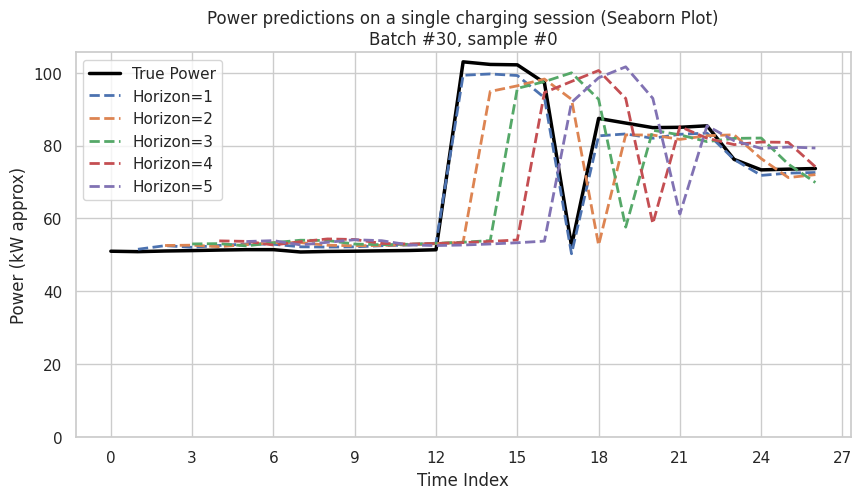

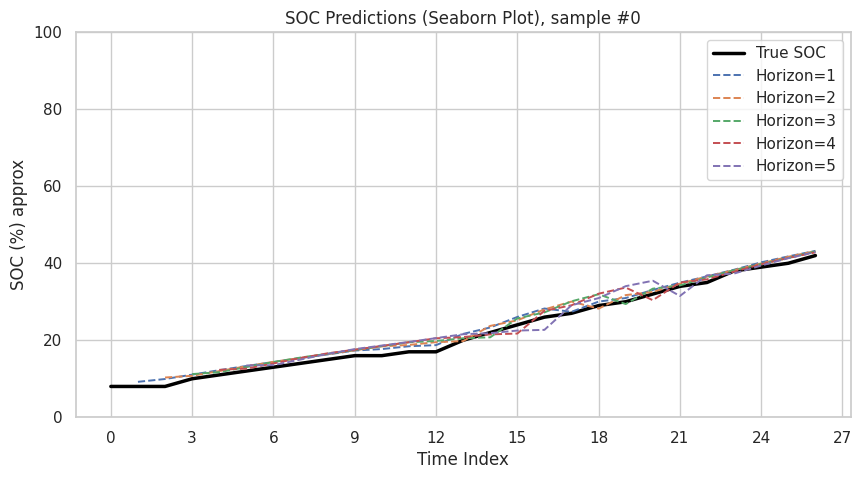

In [35]:
# ---------------------------
# Multi-horizon visualization
# ---------------------------
BATCH_INDEX = 30  
SAMPLE_INDEX = 0
test_loader_iter = iter(test_loader)
for i in range(BATCH_INDEX):
    next(test_loader_iter)
X_test_batch, Y_test_batch, lengths_test = next(test_loader_iter)

print("Batch lengths:", lengths_test)
assert len(lengths_test) == BATCH_SIZE

X_test_batch = X_test_batch.to(device)
Y_test_batch = Y_test_batch.to(device)

model.eval()
with torch.no_grad():
    # y_pred_4d has shape (B, T_max, horizon, num_targets)
    y_pred_4d, out_lengths = model(X_test_batch, lengths_test)

# Pick one sample from this batch
sample_len = lengths_test[SAMPLE_INDEX].item()

# Slice out the valid portion for predictions
pred_sample_4d = y_pred_4d[SAMPLE_INDEX, :sample_len]  # shape (T, horizon, num_targets)
true_sample_4d = Y_test_batch[SAMPLE_INDEX, :sample_len]

# Retrieve original scaled input to include the true values
X_seq_scaled = X_test_batch[SAMPLE_INDEX, :sample_len].cpu().numpy()
idx_power = input_features.index("power")
idx_soc   = input_features.index("soc")
orig_power_scaled = X_seq_scaled[:, [idx_power]]
orig_power_unscaled = power_scaler.inverse_transform(orig_power_scaled).ravel()
orig_soc_scaled = X_seq_scaled[:, [idx_soc]]
orig_soc_unscaled = soc_scaler.inverse_transform(orig_soc_scaled).ravel()

num_horizons = pred_sample_4d.shape[1]
time_indices = np.arange(sample_len)

# ----------------------------------
# Plotting power over time
# ----------------------------------
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10,5))

# Create a DataFrame for the true power series
df_true = pd.DataFrame({
    "Time": time_indices,
    "True Power": orig_power_unscaled
})
sns.lineplot(data=df_true, x="Time", y="True Power", ax=ax,
             color="black", linewidth=2.5, label="True Power")

# Use a Seaborn palette for the horizons
palette = sns.color_palette("deep", n_colors=num_horizons)
for h in range(num_horizons):
    # Exclude t=0 as in training
    pred_for_h = pred_sample_4d[1:, h, 0].cpu().numpy()
    valid_T = sample_len - 1 - h  # prediction at time i predicts time i+h; ensure i+h < sample_len
    if valid_T <= 0:
        continue
    pred_for_h = pred_for_h[:valid_T].reshape(-1, 1)
    pred_power_unscaled = power_scaler.inverse_transform(pred_for_h).ravel()
    
    time_axis_h = np.arange(1, valid_T + 1) + h  # shift the time axis by the horizon
    df_pred = pd.DataFrame({
        "Time": time_axis_h,
        "Predicted Power": pred_power_unscaled
    })
    sns.lineplot(data=df_pred, x="Time", y="Predicted Power", ax=ax,
                 linestyle="--", linewidth=2.0, color=palette[h], label=f"Horizon={h+1}")

ax.set_xlabel("Time Index")
ax.set_ylabel("Power (kW approx)")
ax.set_title(f'Power predictions on a single charging session (Seaborn Plot)\nBatch #{BATCH_INDEX}, sample #{SAMPLE_INDEX}')
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
plt.show()

# ----------------------------------
# Plotting SOC over time
# ----------------------------------
fig, ax = plt.subplots(figsize=(10,5))

df_true_soc = pd.DataFrame({
    "Time": time_indices,
    "True SOC": orig_soc_unscaled
})
sns.lineplot(data=df_true_soc, x="Time", y="True SOC", ax=ax,
             color="black", linewidth=2.5, label="True SOC")

for h in range(num_horizons):
    pred_for_h = pred_sample_4d[1:, h, 1].cpu().numpy()  # for SOC predictions
    valid_T = sample_len - 1 - h
    if valid_T <= 0:
        continue
    pred_for_h = pred_for_h[:valid_T].reshape(-1, 1)
    pred_soc_unscaled = soc_scaler.inverse_transform(pred_for_h).ravel()
    
    time_axis_h = np.arange(1, valid_T + 1) + h
    df_pred_soc = pd.DataFrame({
        "Time": time_axis_h,
        "Predicted SOC": pred_soc_unscaled
    })
    sns.lineplot(data=df_pred_soc, x="Time", y="Predicted SOC", ax=ax,
                 linestyle="--", linewidth=1.4, color=palette[h], label=f"Horizon={h+1}")

ax.set_xlabel("Time Index")
ax.set_ylabel("SOC (%) approx")
ax.set_title(f'SOC Predictions (Seaborn Plot), sample #{SAMPLE_INDEX}')
ax.set_ylim(0, 100)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
plt.show()


Multi-sample, multi-horizon grid plot

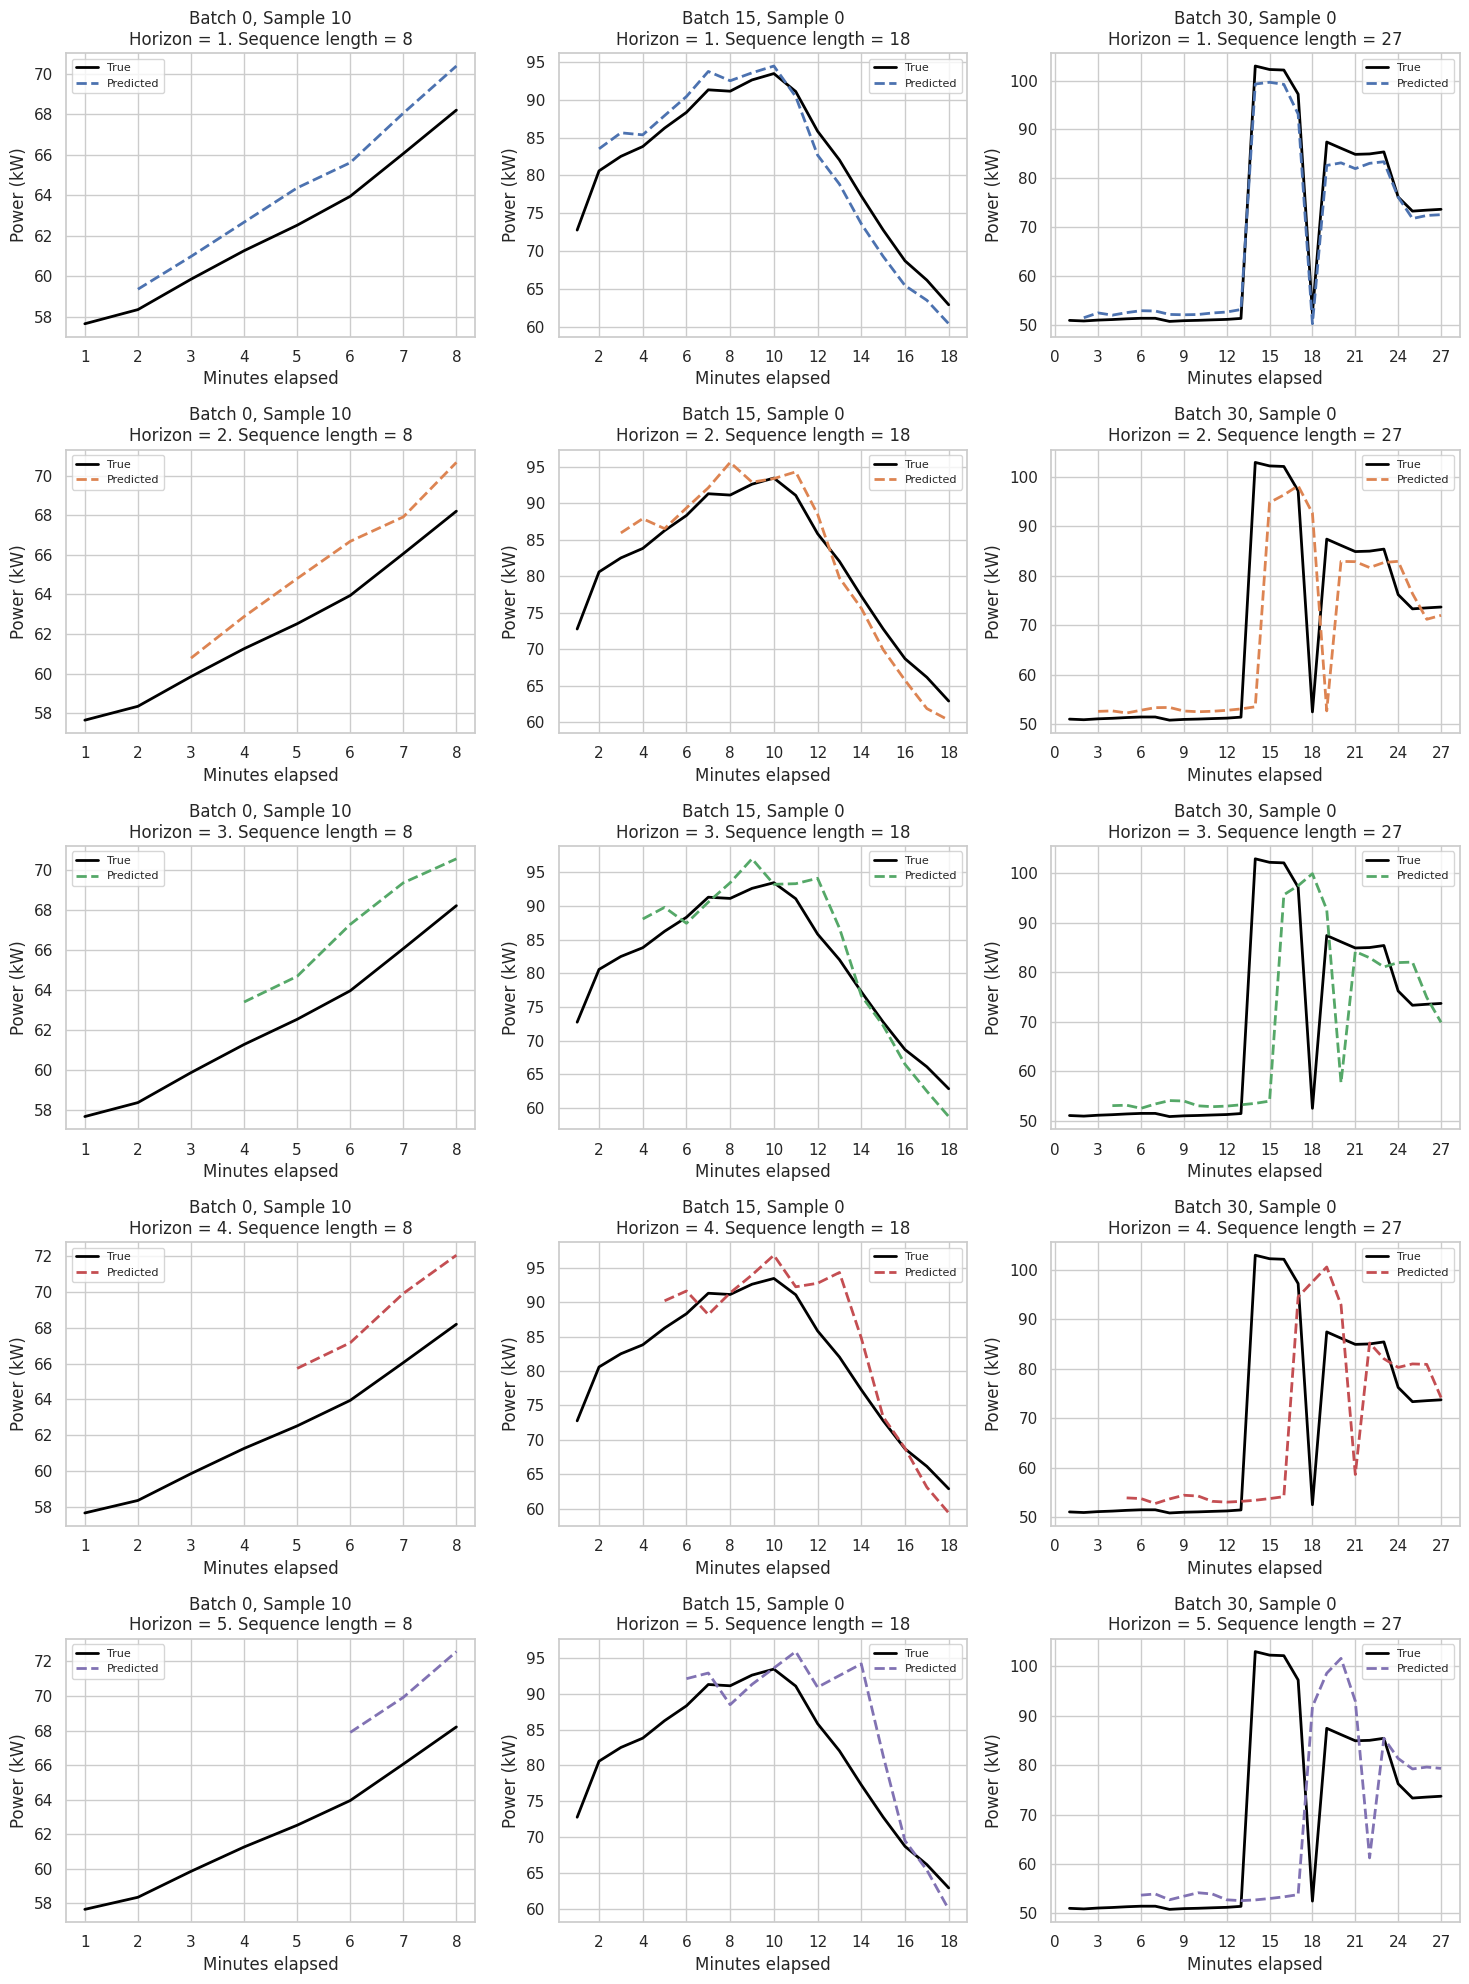

In [37]:
import seaborn as sns
import matplotlib.ticker as ticker
sns.set_theme(style="whitegrid")

# ===== NEW CELL: Multi-sample, multi-horizon grid plot (Seaborn) =====
# User-specified batch and sample indices
batch_indices  = [0, 15, 30]    # which batches (from test_loader) to use
sample_indices = [10, 0, 0]      # which sample in each selected batch

# To store predictions, sequence lengths, and original input sequences for each selected sample.
predictions_list = []   # each element: tensor of shape (T, horizon, num_targets)
seq_lengths_list = []   # true length (number of valid timesteps) for each sample
input_list = []         # original input sequence X (for true power)

model.eval()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

for b_idx, s_idx in zip(batch_indices, sample_indices):
    test_iter = iter(test_loader)
    for _ in range(b_idx):
        next(test_iter)
    X_batch, Y_batch, lengths_batch = next(test_iter)
    
    if s_idx >= X_batch.shape[0]:
        raise ValueError(f"Sample index {s_idx} not available in batch {b_idx}.")
        
    sample_len = lengths_batch[s_idx].item()
    seq_lengths_list.append(sample_len)
    
    # Save the original input for true power series (only valid timesteps)
    X_sample = X_batch[s_idx, :sample_len].cpu()  # shape (T, input_size)
    input_list.append(X_sample)
    
    # Run the model on the batch and extract predictions for this sample (only valid timesteps)
    X_batch = X_batch.to(device)
    with torch.no_grad():
        y_pred_4d, _ = model(X_batch, lengths_batch)
    pred_sample = y_pred_4d[s_idx, :sample_len].cpu()  # shape (T, horizon, num_targets)
    predictions_list.append(pred_sample)

# We assume HORIZON is the same across samples (should be 5)
HORIZON = predictions_list[0].shape[1]
num_samples = len(predictions_list)

fig, axes = plt.subplots(nrows=HORIZON, ncols=num_samples, figsize=(5*num_samples, 4*HORIZON),
                         sharex=False, sharey=False)
if num_samples == 1:
    axes = axes[:, None]

# Determine the index of the "power" feature in the input features
idx_power = input_features.index("power")
palette = sns.color_palette("deep", n_colors=HORIZON)

for col in range(num_samples):
    sample_len = seq_lengths_list[col]
    pred_sample = predictions_list[col]  # shape (T, horizon, num_targets)
    X_sample = input_list[col].numpy()     # shape (T, input_size)
    
    # Get the full true power series from the input.
    true_power_scaled = X_sample[:, idx_power].reshape(-1, 1)
    true_power_unscaled = power_scaler.inverse_transform(true_power_scaled).ravel()
    if true_power_unscaled[-1] == 0:
        true_power_unscaled = true_power_unscaled[:-1]
    # Create a time axis for the full true series starting at 1
    true_time_axis = np.arange(1, len(true_power_unscaled)+1)
    
    for h in range(HORIZON):
        ax = axes[h, col]
        
        # Check if the first prediction (at index 1) is nearly 0 (likely padded);
        # if so, start at the next valid time step.
        start_idx = 1
        first_pred_value = pred_sample[start_idx, h, 0].item()
        if np.isclose(first_pred_value, 0.0, atol=1e-6):
            start_idx = 2
        
        valid_length = sample_len - start_idx - h
        if valid_length <= 0:
            ax.text(0.5, 0.5, "No valid predictions", ha="center", va="center")
            continue
        
        pred_h = pred_sample[start_idx : start_idx + valid_length, h, 0].numpy().reshape(-1, 1)
        pred_h_unscaled = power_scaler.inverse_transform(pred_h).ravel()
        # For a prediction at time i (starting from our start index), the target is at time i+h.
        pred_time_axis = np.arange(start_idx+1, start_idx + valid_length+1) + h
        
        # Create DataFrames for true and predicted series
        df_true = pd.DataFrame({
            "Minutes": true_time_axis,
            "True Power": true_power_unscaled
        })
        df_pred = pd.DataFrame({
            "Minutes": pred_time_axis,
            "Predicted Power": pred_h_unscaled
        })
        # Plot the true power series as a solid black line
        sns.lineplot(data=df_true, x="Minutes", y="True Power", ax=ax,
                     color="black", linewidth=2, label="True")
        # Overlay the predicted series as a dashed line
        sns.lineplot(data=df_pred, x="Minutes", y="Predicted Power", ax=ax,
                     linestyle="--", linewidth=2, color=palette[h], label="Predicted")
        
        ax.set_title(f"Batch {batch_indices[col]}, Sample {sample_indices[col]}\nHorizon = {h+1}. Sequence length = {len(true_power_unscaled)}")
        ax.set_xlabel("Minutes elapsed")
        ax.set_ylabel("Power (kW)")
        ax.grid(True)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Anomaly Detection